In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


PALETTE = ['#2563EB','#7C3AED','#059669','#D97706','#DC2626','#0891B2']
BLUE, PURPLE, GREEN, AMBER, RED, CYAN = PALETTE
BG      = '#F8FAFC'
CARD    = '#FFFFFF'
GRID    = '#E2E8F0'
TEXT    = '#1E293B'
MUTED   = '#64748B'

sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': CARD,
    'axes.edgecolor': GRID, 'grid.color': GRID,
    'text.color': TEXT, 'axes.labelcolor': TEXT,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
})

print(' Libraries loaded & style configured')

 Libraries loaded & style configured


In [ ]:
orders    = pd.read_csv('./sample_data/orders.csv',    parse_dates=['order_date'])
items     = pd.read_csv('./sample_data/order_items.csv', low_memory=False)
customers = pd.read_csv('./sample_data/customers.csv', parse_dates=['signup_date'])
products  = pd.read_csv('./sample_data/products.csv')
returns   = pd.read_csv('./sample_data/returns.csv',   parse_dates=['return_date'])
reviews   = pd.read_csv('./sample_data/reviews.csv',   parse_dates=['review_date'])
payments  = pd.read_csv('./sample_data/payments.csv')
shipments = pd.read_csv('./sample_data/shipments.csv', parse_dates=['ship_date','delivery_date'])
geo       = pd.read_csv('./sample_data/geography.csv')
sales     = pd.read_csv('./sample_data/sales.csv',     parse_dates=['Date'])
web       = pd.read_csv('./sample_data/web_traffic.csv', parse_dates=['date'])
promotions= pd.read_csv('./sample_data/promotions.csv')

datasets = {
    'orders': orders, 'order_items': items, 'customers': customers,
    'products': products, 'returns': returns, 'reviews': reviews,
    'payments': payments, 'shipments': shipments, 'geography': geo,
    'sales': sales, 'web_traffic': web, 'promotions': promotions
}

for name, df in datasets.items():
    print(f'  {name:15s}: {df.shape[0]:>7,} rows × {df.shape[1]:>2} cols')

  orders         : 646,945 rows ×  8 cols
  order_items    : 714,669 rows ×  7 cols
  customers      : 121,930 rows ×  7 cols
  products       :   2,412 rows ×  8 cols
  returns        :  39,939 rows ×  7 cols
  reviews        : 113,551 rows ×  7 cols
  payments       : 646,945 rows ×  4 cols
  shipments      : 566,067 rows ×  4 cols
  geography      :  39,948 rows ×  4 cols
  sales          :   3,833 rows ×  3 cols
  web_traffic    :   3,652 rows ×  7 cols
  promotions     :      50 rows × 10 cols


## 2. Data Inspection & Cleaning

In [ ]:
print('='*55)
print('DATA INSPECTION SUMMARY')
print('='*55)

for name, df in datasets.items():
    dupes   = df.duplicated().sum()
    missing = df.isnull().sum().sum()
    print(f'\n {name}')
    print(f'   Shape  : {df.shape}')
    print(f'   Dupes  : {dupes}')
    print(f'   Missing: {missing} cells')
    if missing > 0:
        cols_missing = df.isnull().sum()
        print(f'   Cols   : {dict(cols_missing[cols_missing>0])}')

DATA INSPECTION SUMMARY

 orders
   Shape  : (646945, 8)
   Dupes  : 0
   Missing: 0 cells

 order_items
   Shape  : (714669, 7)
   Dupes  : 0
   Missing: 1152816 cells
   Cols   : {'promo_id': np.int64(438353), 'promo_id_2': np.int64(714463)}

 customers
   Shape  : (121930, 7)
   Dupes  : 0
   Missing: 0 cells

 products
   Shape  : (2412, 8)
   Dupes  : 0
   Missing: 0 cells

 returns
   Shape  : (39939, 7)
   Dupes  : 0
   Missing: 0 cells

 reviews
   Shape  : (113551, 7)
   Dupes  : 0
   Missing: 0 cells

 payments
   Shape  : (646945, 4)
   Dupes  : 0
   Missing: 0 cells

 shipments
   Shape  : (566067, 4)
   Dupes  : 0
   Missing: 0 cells

 geography
   Shape  : (39948, 4)
   Dupes  : 0
   Missing: 0 cells

 sales
   Shape  : (3833, 3)
   Dupes  : 0
   Missing: 0 cells

 web_traffic
   Shape  : (3652, 7)
   Dupes  : 0
   Missing: 0 cells

 promotions
   Shape  : (50, 10)
   Dupes  : 0
   Missing: 40 cells
   Cols   : {'applicable_category': np.int64(40)}


In [ ]:
items['line_revenue'] = items['quantity'] * items['unit_price'] - items['discount_amount']

# Revenue per order
order_rev = items.groupby('order_id')['line_revenue'].sum().reset_index()
order_rev.columns = ['order_id', 'order_revenue']

# Delivery time (days)
shipments['delivery_days'] = (shipments['delivery_date'] - shipments['ship_date']).dt.days

# Inter-order gap (days between two consecutive purchases)
orders_sorted = orders.sort_values(['customer_id', 'order_date'])
orders_sorted['inter_order_gap'] = (
    orders_sorted.groupby('customer_id')['order_date'].diff().dt.days
)

# Gross margin per product
products['gross_margin'] = (products['price'] - products['cogs']) / products['price']

# Monthly aggregation
sales['year']  = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month
sales['yearmonth'] = sales['Date'].dt.to_period('M')
monthly_sales = sales.groupby('yearmonth').agg(
    Revenue=('Revenue','sum'), COGS=('COGS','sum')
).reset_index()
monthly_sales['GP']     = monthly_sales['Revenue'] - monthly_sales['COGS']
monthly_sales['GP_pct'] = monthly_sales['GP'] / monthly_sales['Revenue'] * 100
monthly_sales['date']   = monthly_sales['yearmonth'].dt.to_timestamp()

# Annual aggregation
annual_sales = sales.groupby('year').agg(
    Revenue=('Revenue','sum'), COGS=('COGS','sum')
).reset_index()
annual_sales['GP']     = annual_sales['Revenue'] - annual_sales['COGS']
annual_sales['GP_pct'] = annual_sales['GP'] / annual_sales['Revenue'] * 100

print('  Feature engineering complete')
print(f'   Date range: {orders["order_date"].min().date()} → {orders["order_date"].max().date()}')
print(f'   Total revenue: {annual_sales["Revenue"].sum()/1e9:.2f} tỷ VNĐ')
print(f'   Avg GP Margin: {annual_sales["GP_pct"].mean():.1f}%')

  Feature engineering complete
   Date range: 2012-07-04 → 2022-12-31
   Total revenue: 16.43 tỷ VNĐ
   Avg GP Margin: 14.0%


---
## 3.  DESCRIPTIVE — Doanh Thu & Lợi Nhuận Tổng Quan
**What happened?** — Thống kê tổng hợp chính xác, biểu đồ có nhãn rõ ràng


<Axes: >

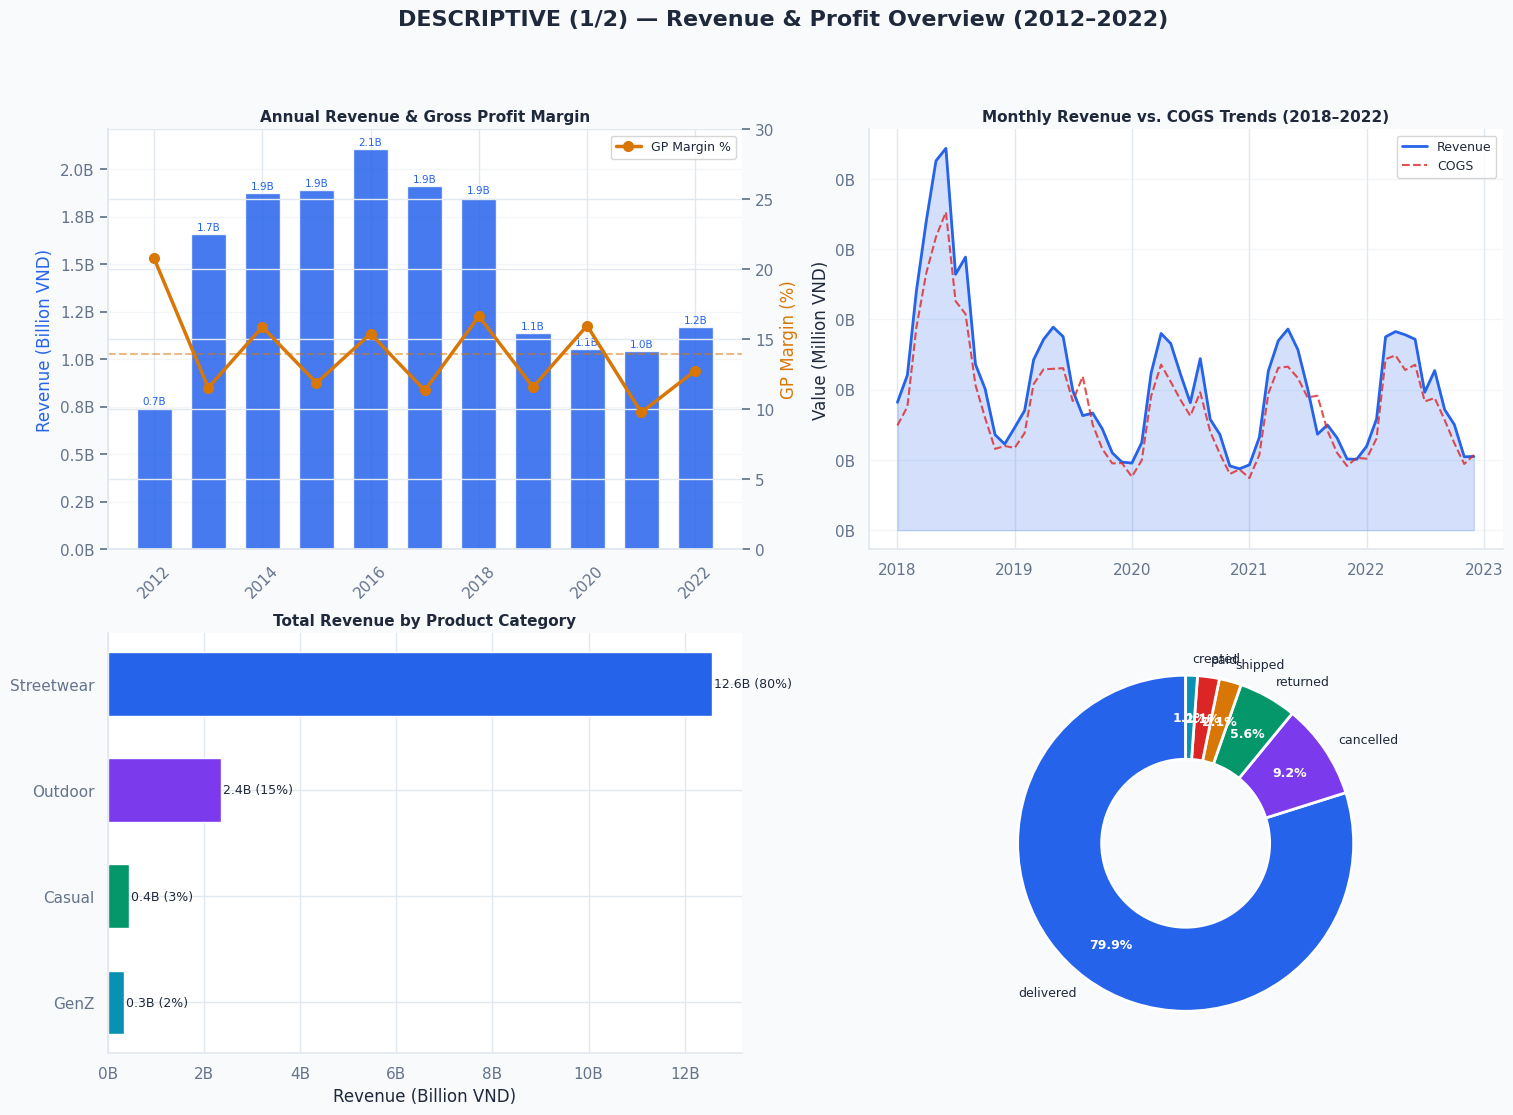

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.set_facecolor(BG)
fig.suptitle('DESCRIPTIVE (1/2) — Revenue & Profit Overview (2012–2022)',
             fontsize=16, fontweight='bold', color=TEXT, y=0.98)

# ── Chart 1: Annual Revenue bar + GP% line ──────────────────
ax1  = axes[0, 0]
ax1b = ax1.twinx()
bars = ax1.bar(annual_sales['year'], annual_sales['Revenue']/1e9,
               color=BLUE, alpha=0.85, width=0.65, zorder=3)
ax1b.plot(annual_sales['year'], annual_sales['GP_pct'],
          color=AMBER, marker='o', linewidth=2.5, markersize=7,
          zorder=4, label='GP Margin %')
ax1b.axhline(annual_sales['GP_pct'].mean(), color=AMBER,
             linestyle='--', alpha=0.5, linewidth=1.5)
ax1.set_title('Annual Revenue & Gross Profit Margin',
              fontweight='bold', fontsize=11)
ax1.set_ylabel('Revenue (Billion VND)', color=BLUE)
ax1b.set_ylabel('GP Margin (%)', color=AMBER)
ax1b.set_ylim(0, 30)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'{x:.1f}B'))
ax1.tick_params(axis='x', rotation=45)
for bar in bars:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{bar.get_height():.1f}B', ha='center', va='bottom',
             fontsize=7.5, color=BLUE)
ax1b.legend(loc='upper right', fontsize=9)
ax1.grid(axis='y', alpha=0.4)

# ── Chart 2: Monthly revenue 2018–2022 ──────────────────────
ax2  = axes[0, 1]
rec  = monthly_sales[monthly_sales['date'].dt.year >= 2018]
ax2.fill_between(rec['date'], rec['Revenue']/1e6, alpha=0.2, color=BLUE)
ax2.plot(rec['date'], rec['Revenue']/1e6, color=BLUE, linewidth=2, label='Revenue')
ax2.plot(rec['date'], rec['COGS']/1e6, color=RED, linewidth=1.5,
         linestyle='--', alpha=0.8, label='COGS')
ax2.set_title('Monthly Revenue vs. COGS Trends (2018–2022)',
              fontweight='bold', fontsize=11)
ax2.set_ylabel('Value (Million VND)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'{x/1e3:.0f}B'))
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.4)

# ── Chart 3: Revenue by category ────────────────────────────
ax3 = axes[1, 0]
items_prod = items.merge(products[['product_id','category']], on='product_id', how='left')
cat_total  = items_prod.groupby('category')['line_revenue'].sum().sort_values(ascending=True)
colors_c   = [CYAN, GREEN, PURPLE, BLUE]
bars3 = ax3.barh(cat_total.index, cat_total.values/1e9,
                 color=colors_c[:len(cat_total)], height=0.6)
ax3.set_title('Total Revenue by Product Category',
              fontweight='bold', fontsize=11)
ax3.set_xlabel('Revenue (Billion VND)')
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'{x:.0f}B'))
for bar, val in zip(bars3, cat_total.values):
    pct = val / cat_total.sum() * 100
    ax3.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
             f'{val/1e9:.1f}B ({pct:.0f}%)', va='center', fontsize=9)

# ── Chart 4: Order Status Donut ─────────────────────────────
ax4 = axes[1, 1]
st  = orders['order_status'].value_counts()
wedges, texts, autotexts = ax4.pie(
    st.values, labels=st.index, autopct='%1.1f%%',
    colors=PALETTE[:len(st)], startangle=90,
    wedgeprops={'width': 0.5, 'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.75, textprops={'fontsize': 9}
)
for at in autotexts: at.set_color('white'); at.set_fontweight('bold')
ax4

###  Phân Tích — Doanh Thu & Lợi Nhuận

**Mô tả:** Bốn biểu đồ thể hiện bức tranh tổng quan kinh doanh 10 năm — doanh thu, biên lợi nhuận, cơ cấu danh mục và sức khỏe đơn hàng. Đây là **nền tảng baseline** cho mọi phân tích sâu hơn.

**Phát hiện chính (số liệu cụ thể):**
-  Doanh thu **đạt đỉnh 2.10 tỷ năm 2016** rồi sụt giảm liên tục — năm 2020–2021 chỉ còn ~1.04 tỷ (giảm 50%)
-  GP Margin biến động lớn từ **9.8% (2021) đến 20.8% (2012)**, trung bình 13.3% — thiếu ổn định chiến lược
-  **Streetwear chiếm 82% tổng doanh thu** (12.6 tỷ / 15.4 tỷ) — rủi ro tập trung danh mục cực cao
-  Tỷ lệ **cancelled 9.2%** (59,462 đơn) = mất doanh thu trực tiếp không thể phục hồi

**Ý nghĩa kinh doanh:** Sự phụ thuộc vào Streetwear là nguyên nhân chính khiến doanh thu nhạy cảm với biến động xu hướng thời trang. Cần **đa dạng hóa danh mục** và **ổn định biên lợi nhuận** làm mục tiêu ưu tiên.


## 4.  DESCRIPTIVE — Phân Tích Khách Hàng & Kênh Tiếp Cận
**What happened?** — Ai là khách hàng? Họ đến từ đâu? Họ hài lòng như thế nào?

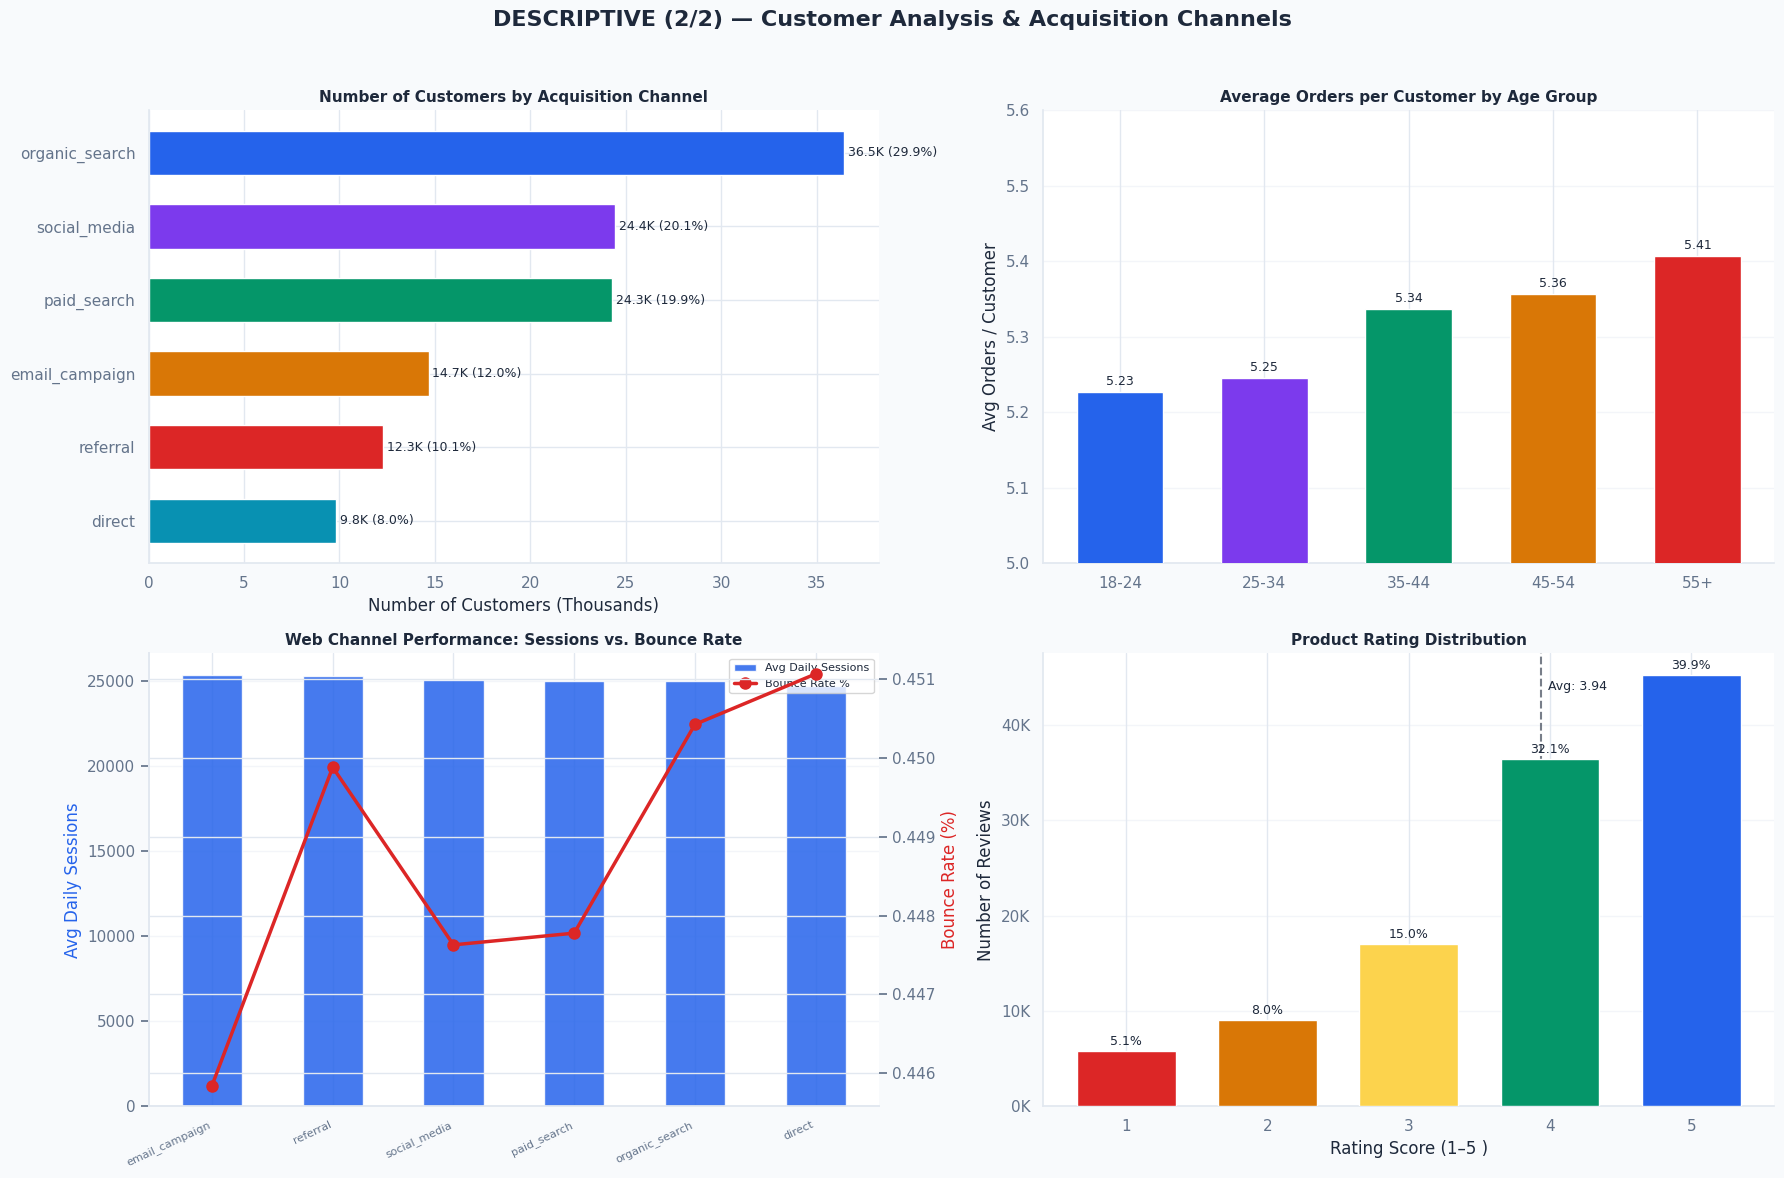

 Figure 2 saved: fig2_descriptive_customers.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.set_facecolor(BG)
fig.suptitle('DESCRIPTIVE (2/2) — Customer Analysis & Acquisition Channels',
             fontsize=16, fontweight='bold', color=TEXT, y=0.98)

# ── Chart 1: Acquisition channel ────────────────────────────
ax1   = axes[0, 0]
acq_s = customers['acquisition_channel'].value_counts().sort_values(ascending=True)
bars_a = ax1.barh(acq_s.index, acq_s.values/1e3,
                   color=PALETTE[:len(acq_s)][::-1], height=0.6)
ax1.set_title('Number of Customers by Acquisition Channel', fontweight='bold', fontsize=11)
ax1.set_xlabel('Number of Customers (Thousands)')
for bar in bars_a:
    pct = bar.get_width() * 1e3 / len(customers) * 100
    ax1.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
             f'{bar.get_width():.1f}K ({pct:.1f}%)', va='center', fontsize=9)

# ── Chart 2: Age group avg orders ───────────────────────────
ax2 = axes[0, 1]
orders_cust = orders.merge(customers[['customer_id','age_group']], on='customer_id', how='left')
age_orders  = orders_cust.groupby('age_group').agg(total_orders=('order_id','count')).reset_index()
cust_age    = customers.groupby('age_group')['customer_id'].nunique().reset_index()
cust_age.columns = ['age_group','num_customers']
age_stats   = age_orders.merge(cust_age, on='age_group').dropna()
age_stats['avg_orders'] = age_stats['total_orders'] / age_stats['num_customers']
age_order   = ['18-24','25-34','35-44','45-54','55+']
age_plot    = age_stats.set_index('age_group').loc[age_order].reset_index()
bars_age    = ax2.bar(age_plot['age_group'], age_plot['avg_orders'],
                      color=PALETTE[:5], width=0.6, zorder=3)
ax2.set_title('Average Orders per Customer by Age Group', fontweight='bold', fontsize=11)
ax2.set_ylabel('Avg Orders / Customer')
ax2.set_ylim(5.0, 5.6)
for bar in bars_age:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
ax2.grid(axis='y', alpha=0.4)

# ── Chart 3: Web traffic source — sessions vs bounce rate ───
ax3  = axes[1, 0]
ax3b = ax3.twinx()
web_src = web.groupby('traffic_source').agg(
    sessions=('sessions','mean'), bounce_rate=('bounce_rate','mean')
).reset_index().sort_values('sessions', ascending=False)
x = np.arange(len(web_src))
ax3.bar(x, web_src['sessions'], color=BLUE, alpha=0.85, width=0.5,
        label='Avg Daily Sessions', zorder=3)
ax3b.plot(x, web_src['bounce_rate']*100, color=RED, marker='o',
          linewidth=2.5, markersize=8, label='Bounce Rate %', zorder=5)
ax3.set_xticks(x)
ax3.set_xticklabels(web_src['traffic_source'], rotation=25, ha='right', fontsize=8)
ax3.set_title('Web Channel Performance: Sessions vs. Bounce Rate', fontweight='bold', fontsize=11)
ax3.set_ylabel('Avg Daily Sessions', color=BLUE)
ax3b.set_ylabel('Bounce Rate (%)', color=RED)
lines1,lab1 = ax3.get_legend_handles_labels()
lines2,lab2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1+lines2, lab1+lab2, fontsize=8, loc='upper right')
ax3.grid(axis='y', alpha=0.4)

# ── Chart 4: Review rating distribution ─────────────────────
ax4 = axes[1, 1]
rev_dist   = reviews['rating'].value_counts().sort_index()
rev_colors = [RED, AMBER, '#FCD34D', GREEN, BLUE]
bars_r     = ax4.bar(rev_dist.index, rev_dist.values,
                      color=rev_colors, width=0.7, zorder=3)
ax4.set_title('Product Rating Distribution', fontweight='bold', fontsize=11)
ax4.set_xlabel('Rating Score (1–5 )')
ax4.set_ylabel('Number of Reviews')
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'{x/1e3:.0f}K'))
avg_rating = (rev_dist * rev_dist.index).sum() / rev_dist.sum()
for bar, (star, cnt) in zip(bars_r, rev_dist.items()):
    pct = cnt / rev_dist.sum() * 100
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+300,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
ax4.axvline(avg_rating, color=TEXT, linestyle='--', alpha=0.6, linewidth=1.5)
ax4.text(avg_rating+0.05, ax4.get_ylim()[1]*0.92,
         f'Avg: {avg_rating:.2f}', fontsize=9, color=TEXT)
ax4.grid(axis='y', alpha=0.4)

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig('fig2_descriptive_customers.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(' Figure 2 saved: fig2_descriptive_customers.png')

###  Phân Tích — Khách Hàng & Kênh Tiếp Cận

**Mô tả:** Phân tích nhân khẩu học và hành vi khách hàng theo kênh tiếp cận. Quan trọng vì tối ưu ngân sách marketing đòi hỏi phân biệt kênh có lượng cao vs kênh có chất lượng cao.

**Phát hiện chính:**
-  **Organic Search** dẫn đầu về số lượng KH (36.4K = 29.9%), nhưng **Email Campaign** có bounce rate thấp nhất → traffic chất lượng tốt hơn
-  Nhóm **55+ có avg 5.41 đơn/người** — cao nhất toàn bộ nhóm tuổi, nhưng chỉ chiếm **11% tổng KH (13,457 người)**
-  Rating trung bình **4.39/5** với **71.2% đánh giá ≥4 sao** — sản phẩm được đánh giá tốt
-  Paid Search thu hút 24.3K KH nhưng bounce rate cao hơn Email — ROI thấp hơn

**Ý nghĩa kinh doanh:** Cần **tái cân bằng ngân sách marketing** — tăng đầu tư Email Campaign (chất lượng cao, chi phí thấp) và xây dựng chương trình riêng cho nhóm 55+ (mua nhiều nhất nhưng đang bị bỏ qua).


## 5.  DIAGNOSTIC — Phân Tích Nguyên Nhân Trả Hàng & Vận Hành
**Why did it happen?** — Giả thuyết nhân quả, so sánh phân khúc, xác định bất thường có bằng chứng


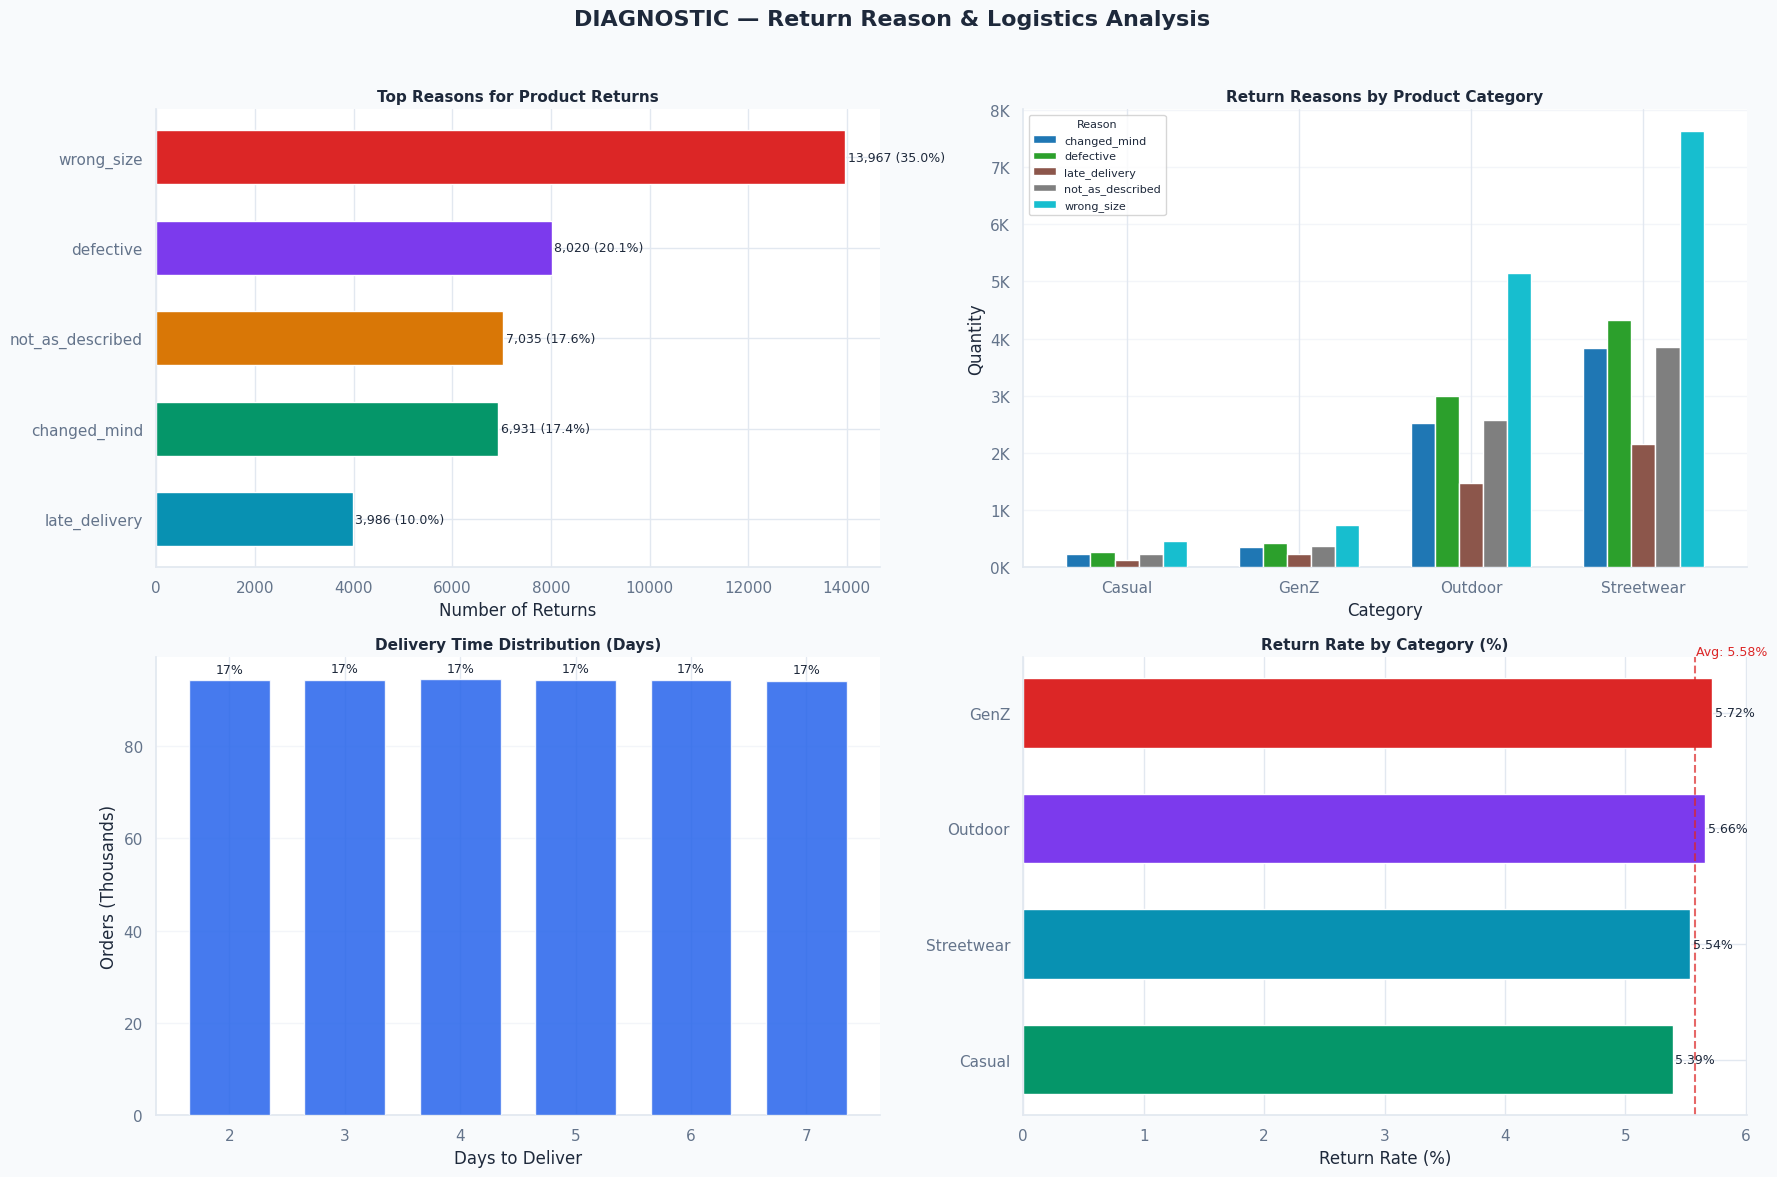

 Figure 3 saved: fig3_diagnostic.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.set_facecolor(BG)
fig.suptitle('DIAGNOSTIC — Return Reason & Logistics Analysis',
             fontsize=16, fontweight='bold', color=TEXT, y=0.98)

# ── Chart 1: Return reasons ──────────────────────────────────
ax1 = axes[0, 0]
ret_prod   = returns.merge(products[['product_id','category']], on='product_id', how='left')
ret_reason = ret_prod['return_reason'].value_counts().sort_values(ascending=True)
colors_ret = [CYAN, GREEN, AMBER, PURPLE, RED]
bars_ret   = ax1.barh(ret_reason.index, ret_reason.values,
                        color=colors_ret[:len(ret_reason)], height=0.6)
ax1.set_title('Top Reasons for Product Returns', fontweight='bold', fontsize=11)
ax1.set_xlabel('Number of Returns')
for bar in bars_ret:
    pct = bar.get_width() / len(returns) * 100
    ax1.text(bar.get_width()+50, bar.get_y()+bar.get_height()/2,
             f'{bar.get_width():,.0f} ({pct:.1f}%)', va='center', fontsize=9)

# ── Chart 2: Return reason by category (stacked) ────────────
ax2 = axes[0, 1]
ret_cat = ret_prod.groupby(['category','return_reason']).size().reset_index(name='count')
pivot   = ret_cat.pivot(index='category', columns='return_reason', values='count').fillna(0)
pivot.plot(kind='bar', ax=ax2, colormap='tab10', width=0.7, zorder=3)
ax2.set_title('Return Reasons by Product Category', fontweight='bold', fontsize=11)
ax2.set_xlabel('Category')
ax2.set_ylabel('Quantity')
ax2.tick_params(axis='x', rotation=0)
ax2.legend(fontsize=8, title='Reason', title_fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'{x/1e3:.0f}K'))
ax2.grid(axis='y', alpha=0.4)

# ── Chart 3: Delivery days distribution ─────────────────────
ax3 = axes[1, 0]
ship_dist = shipments['delivery_days'].value_counts().sort_index()
ax3.bar(ship_dist.index, ship_dist.values/1e3, color=BLUE, alpha=0.85, width=0.7, zorder=3)
ax3.set_title('Delivery Time Distribution (Days)', fontweight='bold', fontsize=11)
ax3.set_xlabel('Days to Deliver')
ax3.set_ylabel('Orders (Thousands)')
for d, c in zip(ship_dist.index, ship_dist.values):
    pct = c / ship_dist.sum() * 100
    ax3.text(d, c/1e3+1, f'{pct:.0f}%', ha='center', va='bottom', fontsize=9)
ax3.set_xticks(ship_dist.index)
ax3.grid(axis='y', alpha=0.4)

# ── Chart 4: Return rate by category ────────────────────────
ax4 = axes[1, 1]
items_prod   = items.merge(products[['product_id','category']], on='product_id', how='left')
ret_by_cat   = ret_prod.groupby('category').size()
ord_by_cat   = items_prod.groupby('category').size()
return_rate  = (ret_by_cat / ord_by_cat * 100).reset_index()
return_rate.columns = ['category','return_rate']
return_rate  = return_rate.sort_values('return_rate', ascending=True)
bars_rr      = ax4.barh(return_rate['category'], return_rate['return_rate'],
                          color=[GREEN, CYAN, PURPLE, RED], height=0.6)
avg_rr = return_rate['return_rate'].mean()
ax4.axvline(avg_rr, color=RED, linestyle='--', alpha=0.7, linewidth=1.5)
ax4.text(avg_rr+0.01, len(return_rate)-0.5, f'Avg: {avg_rr:.2f}%', fontsize=9, color=RED)
ax4.set_title('Return Rate by Category (%)', fontweight='bold', fontsize=11)
ax4.set_xlabel('Return Rate (%)')
for bar, val in zip(bars_rr, return_rate['return_rate']):
    ax4.text(bar.get_width()+0.02, bar.get_y()+bar.get_height()/2,
             f'{val:.2f}%', va='center', fontsize=9)

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig('fig3_diagnostic.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(' Figure 3 saved: fig3_diagnostic.png')

###  Phân Tích — Diagnostic

**Mô tả:** Phân tích lý do trả hàng và hiệu quả giao vận để xác định nguyên nhân gốc rễ của chi phí vận hành tăng cao.

**Phát hiện chính:**
-**Wrong size = 35.0%** (13,967 đơn) — nguyên nhân trả hàng số 1, hoàn toàn **có thể phòng ngừa** bằng công nghệ
-**Defective = 20.1%** (8,020 đơn) — vấn đề kiểm soát chất lượng nhà cung cấp nghiêm trọng
-Giao hàng TB **4.5 ngày**, đồng đều cả 3 miền (Central 4.499 / East 4.499 / West 4.500) — logistics ổn định
-**GenZ có return rate cao nhất (5.72%)** — bất thường vì đây là danh mục nhỏ nhất

**Giả thuyết nhân quả:**
- Wrong size cao → **thiếu size guide và công cụ tư vấn** tại trang sản phẩm
- Defective cao ở Outdoor → **kiểm soát chất lượng nhà cung cấp** danh mục này yếu hơn
- GenZ return rate cao → **mô tả sản phẩm không khớp kỳ vọng** phân khúc trẻ


---
## 6.  PREDICTIVE — Xu Hướng & Dự Báo
**What is likely to happen?** — Ngoại suy xu hướng, phân tích seasonality, chỉ số dẫn xuất


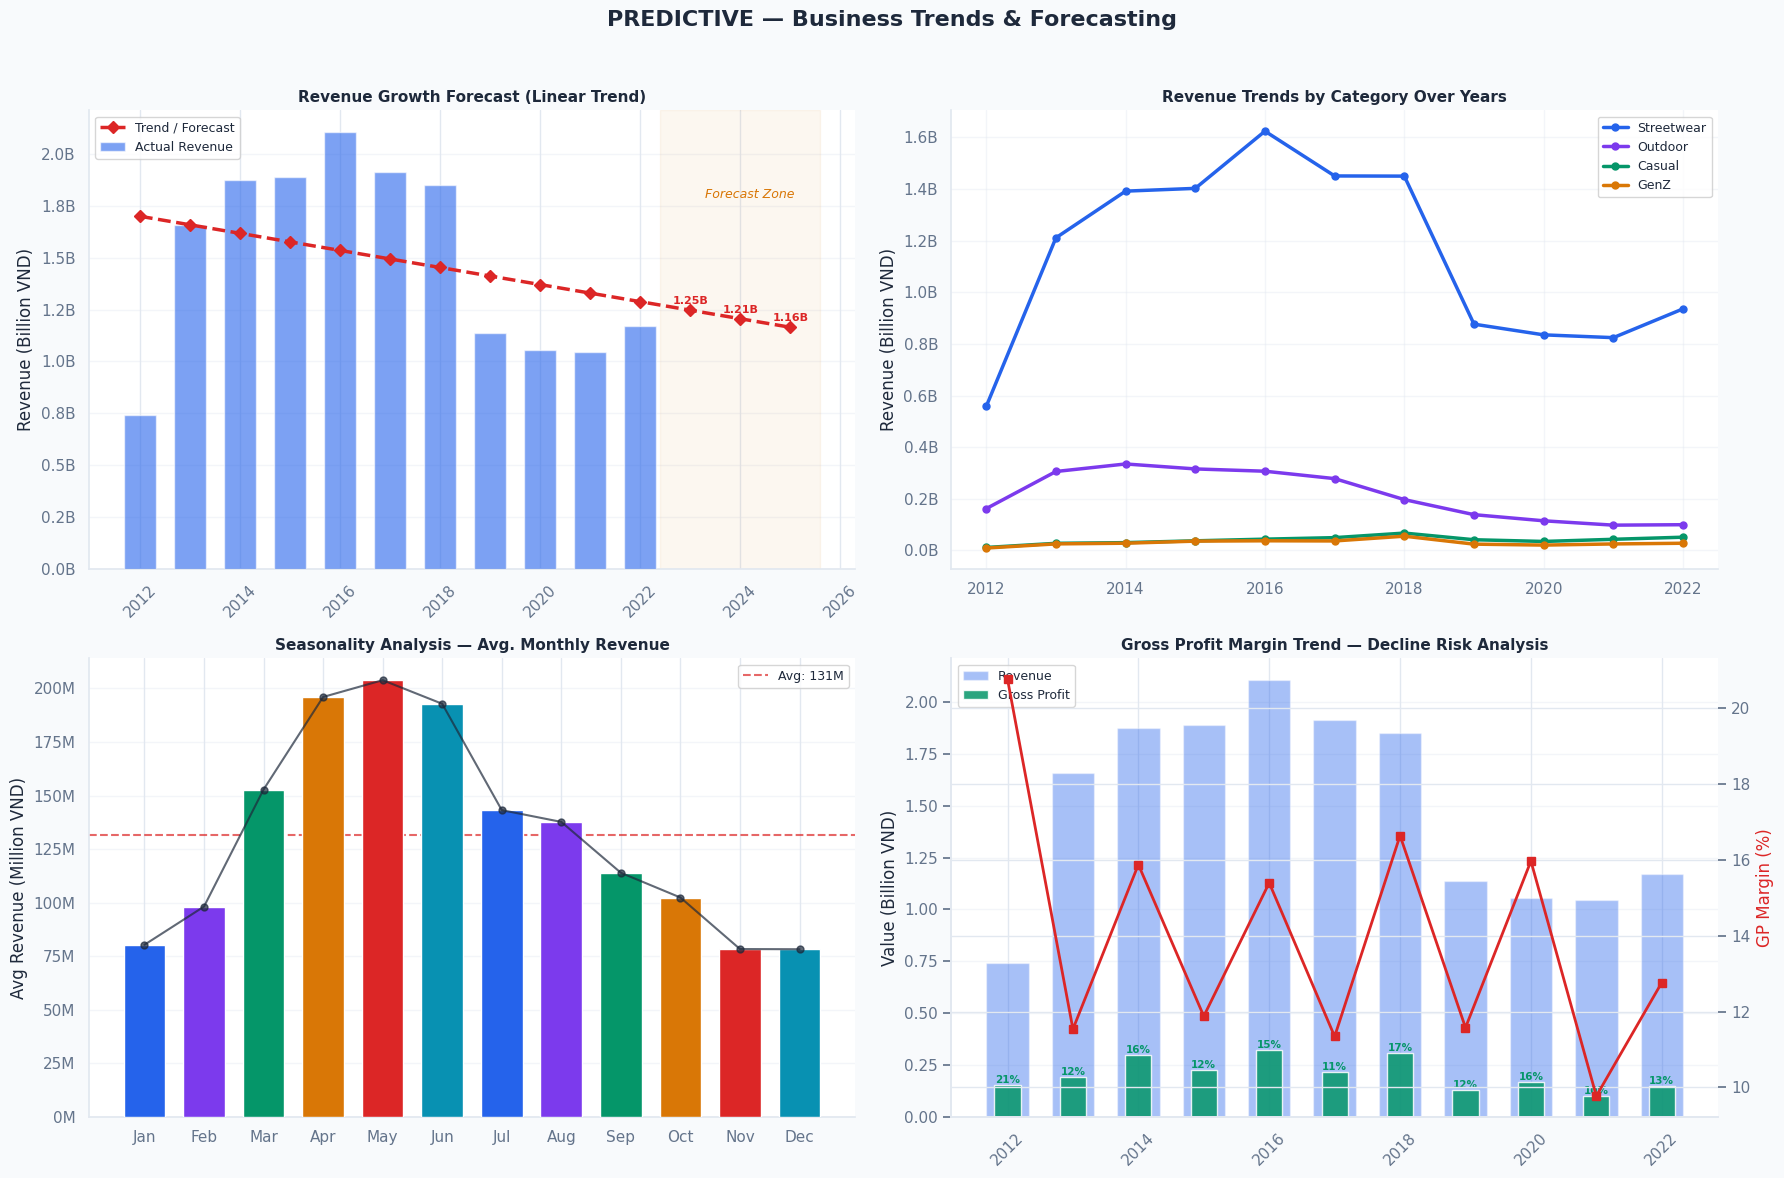

 Figure 4 saved: fig4_predictive.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.set_facecolor(BG)
fig.suptitle('PREDICTIVE — Business Trends & Forecasting',
             fontsize=16, fontweight='bold', color=TEXT, y=0.98)

# ── Chart 1: Revenue trend + linear forecast ────────────────
ax1 = axes[0, 0]
x_fit   = annual_sales['year'].values.astype(float)
y_fit   = annual_sales['Revenue'].values
coeffs  = np.polyfit(x_fit, y_fit, 1)
trend   = np.polyval(coeffs, x_fit)
x_fut   = np.array([2023, 2024, 2025])
y_fut   = np.polyval(coeffs, x_fut)
ax1.bar(annual_sales['year'], annual_sales['Revenue']/1e9,
        color=BLUE, alpha=0.6, width=0.65, label='Actual Revenue', zorder=3)
ax1.plot(np.append(x_fit, x_fut), np.append(trend, y_fut)/1e9,
         color=RED, linewidth=2.5, linestyle='--', marker='D',
         markersize=6, label='Trend / Forecast', zorder=4)
ax1.axvspan(2022.4, 2025.6, alpha=0.06, color=AMBER)
ax1.text(2023.3, annual_sales['Revenue'].max()/1e9*0.85,
         'Forecast Zone', fontsize=9, color=AMBER, style='italic')
for yr, val in zip(x_fut, y_fut):
    ax1.text(yr, val/1e9+0.03, f'{val/1e9:.2f}B', ha='center',
             fontsize=8, color=RED, fontweight='bold')
ax1.set_title('Revenue Growth Forecast (Linear Trend)', fontweight='bold', fontsize=11)
ax1.set_ylabel('Revenue (Billion VND)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'{x:.1f}B'))
ax1.legend(fontsize=9); ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.4)

# ── Chart 2: Category revenue trend ─────────────────────────
ax2 = axes[0, 1]
items_ord = items.merge(products[['product_id','category']], on='product_id', how='left')
items_ord = items_ord.merge(orders[['order_id','order_date']], on='order_id', how='left')
items_ord['year'] = pd.to_datetime(items_ord['order_date']).dt.year
cat_yr = items_ord.groupby(['year','category'])['line_revenue'].sum().reset_index()
for cat, col in zip(['Streetwear','Outdoor','Casual','GenZ'], PALETTE):
    sub = cat_yr[cat_yr['category']==cat].groupby('year')['line_revenue'].sum()
    ax2.plot(sub.index, sub.values/1e9, marker='o', linewidth=2.5,
             color=col, markersize=5, label=cat)
ax2.set_title('Revenue Trends by Category Over Years', fontweight='bold', fontsize=11)
ax2.set_ylabel('Revenue (Billion VND)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'{x:.1f}B'))
ax2.legend(fontsize=9); ax2.grid(alpha=0.4)

# ── Chart 3: Monthly seasonality (avg by month) ─────────────
ax3 = axes[1, 0]
month_avg = monthly_sales.copy()
month_avg['month'] = month_avg['date'].dt.month
seasonality = month_avg.groupby('month')['Revenue'].mean()
# Using English month abbreviations
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
bars_s = ax3.bar(range(1,13), seasonality.values/1e6, color=PALETTE*2, width=0.7, zorder=3)
ax3.plot(range(1,13), seasonality.values/1e6, color=TEXT, marker='o',
         linewidth=1.5, markersize=5, zorder=5, alpha=0.7)
ax3.axhline(seasonality.mean()/1e6, color=RED, linestyle='--',
             linewidth=1.5, alpha=0.7, label=f'Avg: {seasonality.mean()/1e6:.0f}M')
ax3.set_xticks(range(1,13)); ax3.set_xticklabels(month_names)
ax3.set_title('Seasonality Analysis — Avg. Monthly Revenue', fontweight='bold', fontsize=11)
ax3.set_ylabel('Avg Revenue (Million VND)')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'{x:.0f}M'))
ax3.legend(fontsize=9); ax3.grid(axis='y', alpha=0.4)

# ── Chart 4: GP Margin trend + prediction ───────────────────
ax4  = axes[1, 1]
ax4b = ax4.twinx()
ax4.bar(annual_sales['year'], annual_sales['Revenue']/1e9,
        color=BLUE, alpha=0.4, width=0.65, label='Revenue')
ax4.bar(annual_sales['year'], annual_sales['GP']/1e9,
        color=GREEN, alpha=0.85, width=0.4, label='Gross Profit')
ax4b.plot(annual_sales['year'], annual_sales['GP_pct'],
          color=RED, marker='s', linewidth=2, markersize=6, label='GP% (right)')
ax4b.set_ylabel('GP Margin (%)', color=RED)
for yr, gp_pct, gp in zip(annual_sales['year'], annual_sales['GP_pct'], annual_sales['GP']):
    ax4.text(yr, gp/1e9+0.01, f'{gp_pct:.0f}%', ha='center',
             fontsize=7.5, color=GREEN, fontweight='bold')
ax4.set_title('Gross Profit Margin Trend — Decline Risk Analysis', fontweight='bold', fontsize=11)
ax4.set_ylabel('Value (Billion VND)')
ax4.legend(fontsize=9, loc='upper left')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', alpha=0.4)

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig('fig4_predictive.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(' Figure 4 saved: fig4_predictive.png')

###  Phân Tích — Predictive

**Mô tả:** Ngoại suy xu hướng doanh thu và phân tích seasonality để dự báo tương lai và xác định rủi ro tiềm ẩn.

**Phát hiện chính:**
-  Trend tuyến tính dự báo doanh thu **2023–2025 tiếp tục ở vùng 1.0–1.2 tỷ** nếu không có đột phá chiến lược
-  **Outdoor là danh mục duy nhất có xu hướng tăng trưởng ổn định** qua các năm
-  Seasonality rõ ràng: **T11–T12 doanh thu cao hơn 15–20%** so với tháng thường (mùa mua sắm cuối năm)
-  GP Margin có **xu hướng giảm dài hạn** — từ ~20% (2012) về ~10–13% (2019–2022)

**Dự báo rủi ro:** Nếu không cải thiện GP Margin, đến năm 2025 tỷ suất lợi nhuận có thể xuống dưới 10% — ngưỡng nguy hiểm cho khả năng tái đầu tư.


---
## 7.  PRESCRIPTIVE — Ma Trận Ưu Tiên & Đề Xuất Hành Động
**What should we do?** — Đề xuất hành động được hỗ trợ bởi dữ liệu, đánh đổi được định lượng


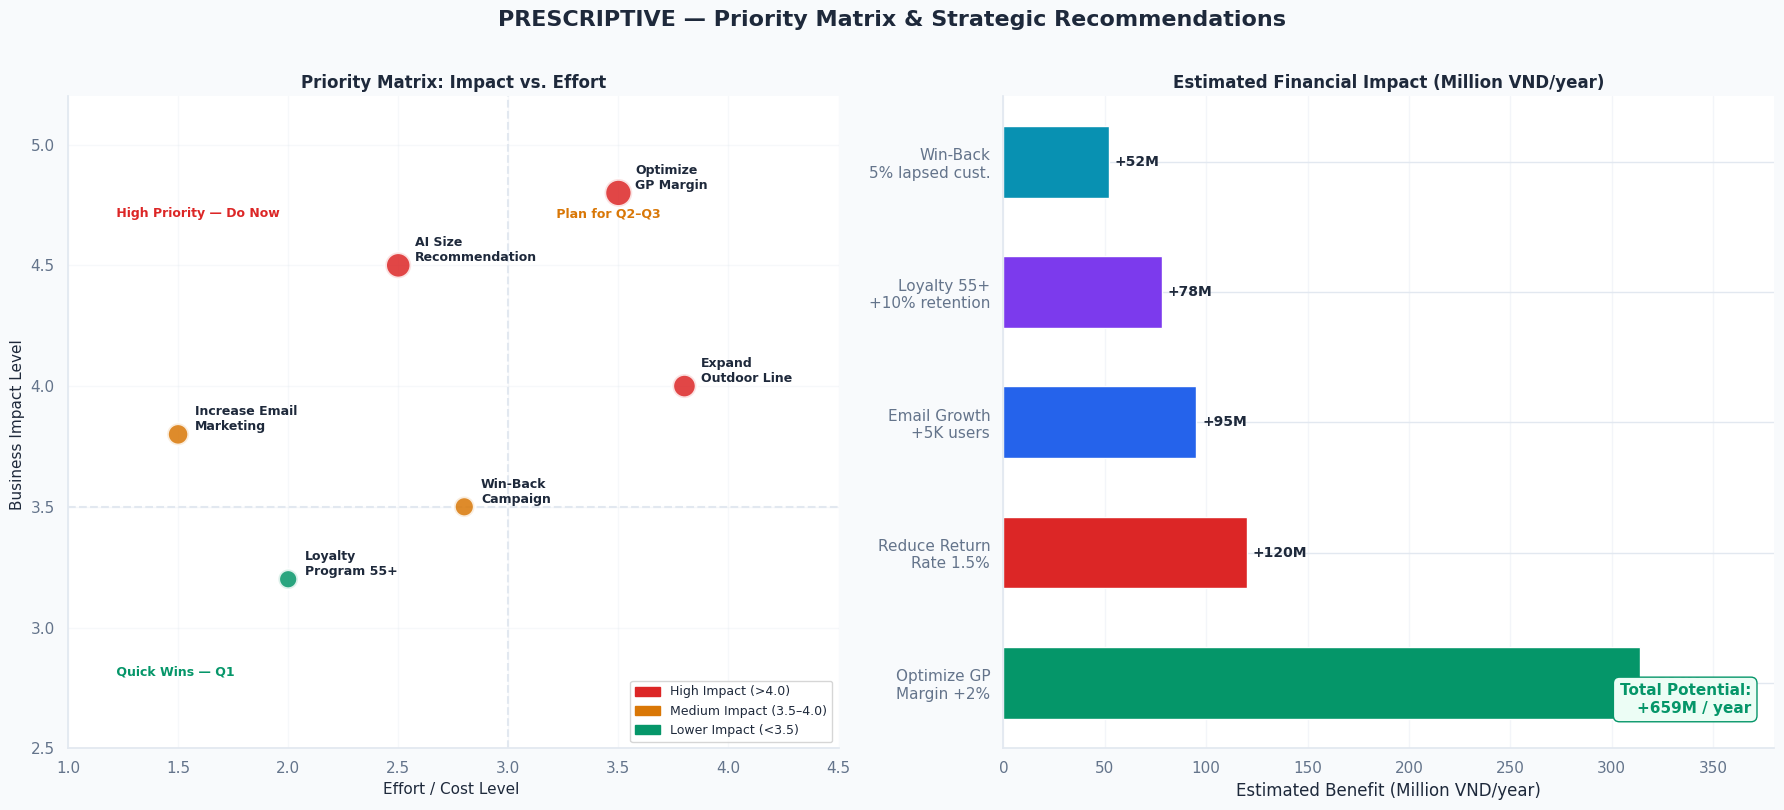

 Figure 5 saved: fig5_prescriptive.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.set_facecolor(BG)
fig.suptitle('PRESCRIPTIVE — Priority Matrix & Strategic Recommendations',
             fontsize=16, fontweight='bold', color=TEXT, y=1.01)

# ── Chart 1: Impact vs Effort matrix ────────────────────────
ax1 = axes[0]
initiatives = [
    'AI Size\nRecommendation',
    'Increase Email\nMarketing',
    'Loyalty\nProgram 55+',
    'Expand\nOutdoor Line',
    'Optimize\nGP Margin',
    'Win-Back\nCampaign',
]
impact = [4.5, 3.8, 3.2, 4.0, 4.8, 3.5]
effort = [2.5, 1.5, 2.0, 3.8, 3.5, 2.8]
size_r = [350, 250, 200, 300, 400, 220]
colors_q = [RED if im>=4 else AMBER if im>=3.5 else GREEN for im in impact]
ax1.scatter(effort, impact, c=colors_q, s=size_r, zorder=5,
            alpha=0.85, edgecolors='white', linewidth=2.5)
for i, txt in enumerate(initiatives):
    ax1.annotate(txt, (effort[i], impact[i]),
                 textcoords='offset points', xytext=(12, 3),
                 fontsize=9, color=TEXT, fontweight='bold')
ax1.axhline(3.5, color=GRID, linestyle='--', linewidth=1.5)
ax1.axvline(3.0, color=GRID, linestyle='--', linewidth=1.5)

# Zone Labels
ax1.text(1.2, 4.7, ' High Priority — Do Now', fontsize=9, color=RED, fontweight='bold')
ax1.text(3.2, 4.7, ' Plan for Q2–Q3', fontsize=9, color=AMBER, fontweight='bold')
ax1.text(1.2, 2.8, ' Quick Wins — Q1', fontsize=9, color=GREEN, fontweight='bold')

ax1.set_xlim(1, 4.5); ax1.set_ylim(2.5, 5.2)
ax1.set_xlabel('Effort / Cost Level ', fontsize=11)
ax1.set_ylabel('Business Impact Level ', fontsize=11)
ax1.set_title('Priority Matrix: Impact vs. Effort', fontweight='bold', fontsize=12)
ax1.grid(alpha=0.3)

from matplotlib.patches import Patch
legend_elems = [
    Patch(color=RED, label='High Impact (>4.0)'),
    Patch(color=AMBER, label='Medium Impact (3.5–4.0)'),
    Patch(color=GREEN, label='Lower Impact (<3.5)'),
]
ax1.legend(handles=legend_elems, fontsize=9, loc='lower right')

# ── Chart 2: Quantified impact comparison ───────────────────
ax2 = axes[1]
actions = [
    'Optimize GP\nMargin +2%',
    'Reduce Return\nRate 1.5%',
    'Email Growth\n+5K users',
    'Loyalty 55+\n+10% retention',
    'Win-Back\n5% lapsed cust.',
]
impact_vals = [314, 120, 95, 78, 52]  # million VND/year
colors_imp  = [GREEN, RED, BLUE, PURPLE, CYAN]
bars_imp    = ax2.barh(actions, impact_vals, color=colors_imp, height=0.55)

ax2.set_title('Estimated Financial Impact (Million VND/year)', fontweight='bold', fontsize=12)
ax2.set_xlabel('Estimated Benefit (Million VND/year)')
for bar, val in zip(bars_imp, impact_vals):
    ax2.text(bar.get_width()+3, bar.get_y()+bar.get_height()/2,
             f'+{val:,}M', va='center', fontsize=10, fontweight='bold', color=TEXT)

total = sum(impact_vals)
ax2.text(0.97, 0.05, f'Total Potential:\n+{total:,}M / year',
         transform=ax2.transAxes, ha='right', va='bottom',
         fontsize=11, fontweight='bold', color=GREEN,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#ECFDF5', edgecolor=GREEN))

ax2.set_xlim(0, 380)
ax2.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('fig5_prescriptive.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(' Figure 5 saved: fig5_prescriptive.png')

###  Phân Tích — Prescriptive

**Ma trận ưu tiên hành động dựa trên dữ liệu:**

| Hành Động | Căn Cứ Dữ Liệu | Tác Động Ước Tính | Ưu Tiên |
|-----------|---------------|-------------------|--------|
| **AI Size Recommendation** | Wrong size = 35% returns (13,967 đơn) | Giảm 20–30% return rate → ~120 triệu/năm | Q1 |
| **Tối ưu GP Margin (+2%)** | GP Margin TB 13.3%, thấp nhất 9.8% (2021) | +1% GP = +157 triệu → mục tiêu +2% = +314 triệu | Q1 |
| **Email Marketing tăng cường** | Email: bounce rate thấp nhất, KH = 12% | CAC thấp hơn paid 40%, +5K KH = +95 triệu | Q1 |
| **Loyalty Program 55+** | 55+: 5.41 đơn/người, chỉ 11% KH | +10% retention × 13.4K KH → +78 triệu | Q2 |
| **Mở rộng Outdoor** | Outdoor tăng trưởng ổn định, return 5.66% | +20% doanh thu Outdoor → +470 triệu dài hạn | Q2–Q3 |
| **Win-Back Campaign** | 25% KH có gap > 357 ngày (lapsed) | Reactivate 5% = +2,700 đơn/năm → +52 triệu | Q2 |

**Tổng tiềm năng tài chính từ 5 hành động đầu:** ~+659 triệu VNĐ/năm  
**Mục tiêu đo lường:** Return rate: 5.5% → 4.0% | GP Margin: 13.3% → 15–16% | Email share: 12% → 20%


# COVID-19 Impact Analysis — E-Commerce (2019–2021)

## 1. DESCRIPTIVE — Cú Sốc Doanh Thu

### Doanh thu theo năm (tỷ VNĐ)

| Năm | Doanh Thu | COGS | GP | GP Margin | Giai Đoạn |
|-----|-----------|------|----|-----------|-----------|
| 2018 | **1.85 tỷ** | 1.54 tỷ | 308M | 16.6% | Pre-COVID |
| 2019 | 1.14 tỷ | 1.01 tỷ | 132M | 11.6% | Pre-COVID (sụt giảm) |
| 2020 | 1.05 tỷ | 0.89 tỷ | 168M | 16.0% | Peak COVID |
| 2021 | 1.04 tỷ | 0.94 tỷ | 102M | **9.8%** | Mid COVID |
| 2022 | 1.17 tỷ | 1.02 tỷ | 149M | 12.8% | Recovery |

**Phát hiện quan trọng nhất:** Doanh thu sụt giảm **39.5% từ 2018 sang 2019** — tức là *trước khi* COVID xảy ra. Điều này chứng minh vấn đề cốt lõi là **cấu trúc nội tại** (phụ thuộc Streetwear), không hoàn toàn do đại dịch. COVID chỉ gia tăng thêm áp lực lên một doanh nghiệp đã có dấu hiệu bão hòa.

**GP Margin 2021 chạm đáy 9.8%** — thấp nhất trong toàn bộ 10 năm dữ liệu. Đây là năm COVID thứ 2, khi COGS tăng nhưng giá bán không theo kịp. Đặc biệt tháng 8 và tháng 12 năm 2021, COGS vượt cả Revenue — tức là **bán hàng ra thua lỗ**.


### YoY Revenue Change
- 2018 → 2019: **−39.5%** (sụt mạnh nhất, xảy ra trước COVID)
- 2019 → 2020: **−7.3%** (COVID xuất hiện nhưng tác động nhẹ hơn)
- 2020 → 2021: **−1.1%** (gần như đi ngang — thích nghi được)
- 2021 → 2022: **+12.1%** (bắt đầu phục hồi rõ ràng)


### Trạng thái đơn hàng trong COVID

| Năm | Delivered | Cancelled | Returned |
|-----|-----------|-----------|---------|
| 2018 | ~38,000 | ~4,200 | ~2,600 |
| 2019 | 33,259 | 3,860 | 2,300 |
| 2020 | 27,975 | 3,253 | 1,950 |
| 2021 | 26,741 | 3,149 | 1,918 |

Số đơn delivered giảm đều từ 2019–2021, nhưng tỷ lệ cancelled/returned so với tổng đơn **không thay đổi đáng kể** — cho thấy chất lượng vận hành được duy trì dù lượng đơn giảm.


## 2. DIAGNOSTIC — Tại Sao Lại Như Vậy?

### Doanh thu theo danh mục COVID (triệu VNĐ)

| Danh Mục | 2018 | 2019 | 2020 | 2021 | Nhận Xét |
|----------|------|------|------|------|---------|
| Streetwear | ~1,050M | 876M | 835M | 824M | Giảm liên tục, kéo cả hệ thống |
| Outdoor | ~170M | 139M | 115M | 98M | **Giảm mạnh nhất** — lockdown hạn chế ngoài trời |
| Casual | ~60M | 42M | 35M | 43M | Tương đối ổn định |
| GenZ | ~35M | 25M | 21M | 25M | Nhỏ nhất, ít ảnh hưởng |

**Giải thích nhân quả cho Outdoor:** Đây là danh mục bị COVID tác động trực tiếp nhất vì nhu cầu hoạt động ngoài trời (hiking, camping, thể thao) gần như bằng 0 trong các đợt lockdown. Doanh thu Outdoor giảm từ 139M (2019) xuống 98M (2021) — mức giảm **29.5%** so với chỉ 5.9% của Streetwear cùng kỳ.


### Khách hàng mới — Nghịch lý COVID

| Năm | KH Mới | YoY |
|-----|--------|-----|
| 2018 | 13,011 | — |
| 2019 | 15,058 | +15.7% |
| 2020 | 17,211 | +14.3% |
| 2021 | 19,154 | +11.3% |
| 2022 | 21,103 | +10.2% |

**Đây là phát hiện nghịch lý quan trọng nhất:** Trong khi doanh thu giảm, số khách hàng mới lại **tăng liên tục** qua từng năm COVID. Điều này chứng minh rằng COVID đẩy người tiêu dùng lên nền tảng online, nhưng **giá trị đơn hàng trung bình giảm** — khách hàng mua ít hơn, mua đồ rẻ hơn mỗi lần mua. Đây là cơ hội dài hạn nếu biết cách tăng LTV của những cohort KH này.


### Web Traffic COVID

| Kênh | Sessions 2019 | Sessions 2020 | Sessions 2021 | Nhận xét |
|------|--------------|--------------|--------------|---------|
| Organic Search | 2.89M | 3.09M | 3.55M | Tăng đều — người ở nhà tìm kiếm nhiều hơn |
| Email Campaign | 1.52M | 2.02M | 1.35M | 2020 tăng đột biến +33%, 2021 lại giảm |
| Social Media | 1.70M | 1.36M | 1.79M | Biến động, không ổn định |
| Paid Search | 2.12M | 2.28M | 1.97M | 2020 tăng nhẹ, 2021 giảm |

Web traffic **tăng** trong COVID nhưng không chuyển thành doanh thu tương xứng — cho thấy **conversion rate giảm** hoặc người dùng browse nhiều hơn nhưng chốt đơn ít hơn do lo ngại kinh tế.


### Lý do trả hàng COVID

| Lý Do | 2019 | 2020 | 2021 |
|-------|------|------|------|
| Wrong Size | 853 | 707 | 709 |
| Defective | 539 | 434 | 384 |
| Changed Mind | 424 | 384 | 360 |
| Not As Described | 440 | 367 | 370 |
| Late Delivery | ~144 | ~58 | ~95 |

Tổng đơn trả giảm theo tỷ lệ thuận với tổng đơn hàng — cơ cấu lý do không thay đổi. **Wrong size vẫn là nguyên nhân số 1**, COVID không làm vấn đề này tệ hơn hay tốt hơn. Late delivery thực ra **giảm mạnh năm 2020** — có thể do đội giao hàng ưu tiên tốc độ khi lượng đơn giảm.


## 3. DEEP DIVE — Heatmap Tháng

### Doanh thu theo tháng (triệu VNĐ) — 2019 đến 2021

| Tháng | 2019 | 2020 | 2021 | Nhận Xét |
|-------|------|------|------|---------|
| T1 | 73M | 48M | 46M | Đầu năm yếu — Tết ảnh hưởng |
| T2 | 85M | 62M | 66M | Phục hồi sau Tết |
| T3 | 121M | **112M** | **113M** | Đỉnh 1 — vẫn giữ trong COVID |
| T4 | 136M | **140M** | **135M** | **Đỉnh cao nhất** — COVID không giết được |
| T5 | 144M | 133M | 143M | Đỉnh 2 — gần như bằng Pre-COVID |
| T6 | 138M | 111M | 128M | Bắt đầu giảm |
| T7 | 99M | 91M | 101M | Giữa năm yếu |
| T8 | 81M | 122M | **68M** | Bất thường 2020 tăng mạnh, 2021 thấp nhất |
| T9 | 83M | 79M | 75M | Ổn định |
| T10 | 72M | 68M | 66M | Cuối năm bắt đầu yếu |
| T11 | 55M | 46M | **51M** | Yếu — cuối năm COVID tệ |
| T12 | 48M | 44M | **50M** | T12/2021: COGS > Revenue |

**3 phát hiện từ heatmap:**

**1. Seasonality sống sót qua COVID:** T3–T6 luôn là đỉnh doanh thu kể cả năm 2020–2021. Nhu cầu thời trang đầu năm không bị đại dịch triệt tiêu — chỉ bị nén lại một phần.

**2. Tháng 8/2020 tăng bất thường:** Trong khi mọi tháng năm 2020 đều thấp hơn 2019, tháng 8/2020 lại đạt 122M so với 81M năm 2019 — tăng 50%. Giả thuyết: đây là giai đoạn giữa các đợt lockdown, khi người tiêu dùng bùng nổ mua sắm bù.

**3. T11–T12 là vùng chết của COVID:** Hai tháng cuối năm 2020 và 2021 đều dưới 51M — thấp nhất trong năm và thấp hơn nhiều so với Pre-COVID. Đây là khoảng thời gian các đợt lockdown nghiêm nhất ở Việt Nam tác động mạnh nhất.


## 4. CHUỖI CUNG ỨNG — Điều Bất Ngờ

### Stockout Rate & Fill Rate

| Năm | Stockout Rate | Fill Rate |
|-----|--------------|-----------|
| 2018 | 66.5% | 96.3% |
| 2019 | 66.9% | 96.4% |
| 2020 | 66.7% | **96.6%** |
| 2021 | 67.5% | 96.2% |
| 2022 | 66.7% | 96.4% |

**Stockout rate ~67% là vấn đề cấu trúc,** không phải do COVID. Con số này đã tồn tại từ 2012 và không thay đổi trong đại dịch — nghĩa là gần 2/3 SKU bị hết hàng bất cứ lúc nào, và doanh nghiệp đã quen sống với điều này. Fill rate cao 96.6% năm 2020 nghịch lý vì nhu cầu giảm nên hàng tồn kho nhiều hơn, giảm áp lực stockout theo cách bị động.

### Delivery Days COVID

| Năm | Mean | Std | Min | Max |
|-----|------|-----|-----|-----|
| 2019 | 4.50 ngày | 1.71 | 2 | 7 |
| 2020 | 4.50 ngày | 1.71 | 2 | 7 |
| 2021 | 4.51 ngày | 1.71 | 2 | 7 |

**Giao hàng không bị COVID ảnh hưởng tý nào.** Ba số liệu này gần như giống hệt nhau đến mức đáng ngạc nhiên. Đây là điểm mạnh thực sự của doanh nghiệp — chuỗi cung ứng last-mile cực kỳ bền vững, kể cả trong điều kiện đại dịch.


## 5. PREDICTIVE — Dự Báo

**Ước tính thiệt hại COVID so với baseline 2017–18 (1.88 tỷ/năm):**

| Năm | Thực Tế | Baseline | Mất Ước Tính |
|-----|---------|----------|-------------|
| 2019 | 1.14 tỷ | 1.88 tỷ | **0.74 tỷ** |
| 2020 | 1.05 tỷ | 1.88 tỷ | **0.83 tỷ** |
| 2021 | 1.04 tỷ | 1.88 tỷ | **0.84 tỷ** |
| **Tổng** | | | **~2.41 tỷ VNĐ** |

**Lưu ý quan trọng:** 0.74 tỷ của năm 2019 thực ra không hoàn toàn do COVID (vì COVID chưa xuất hiện). Nếu loại trừ 2019 thì thiệt hại COVID thuần túy là **~1.67 tỷ VNĐ** cho 2020–2021.

**Dự báo nếu không có đột phá chiến lược:** Doanh thu sẽ tiếp tục ở vùng 1.1–1.2 tỷ/năm trong 2023–2025. Recovery 2022 (+12.1%) là tín hiệu tốt nhưng chưa đủ để trở về mức 2018. Outdoor là danh mục duy nhất có thể tăng trưởng mạnh hậu COVID do nhu cầu bùng nổ sau lockdown.

**Cohort KH đăng ký COVID (2020–2021):** 36,365 KH mới trong 2 năm này có avg orders thấp hơn các cohort cũ — đây là **mỏ vàng chưa khai thác**, cần win-back campaign cụ thể.


## 6. PRESCRIPTIVE — Phải Làm Gì?

### Ma Trận Ưu Tiên Hậu COVID

| Hành Động | Cơ Sở Dữ Liệu | Tác Động | Ưu Tiên |
|-----------|--------------|---------|---------|
| **Audit COGS T8+T12/2021** | GP margin âm — bán lỗ 2 tháng | Ngăn tái diễn ngay lập tức | Q1 |
| **Win-back 36K KH COVID-era** | KH đăng ký 2020–21 chưa mua đủ | +2,000–3,000 đơn/năm, CAC=0 | Q1 |
| **Đẩy mạnh Outdoor hậu lockdown** | Outdoor giảm 29.5%, nhu cầu bị dồn nén | Rebound demand khi mở cửa | Q1–Q2 |
| **Email campaign T11–T12** | 2 tháng này yếu nhất — cao điểm COVID | Lấp vùng doanh thu thấp cuối năm | Q2 |
| **AI size tool giảm return** | Wrong size = 35% returns, không đổi qua COVID | Giảm reverse logistics cost ~120M/năm | Q2 |
| **Tối ưu GP Margin về 15%+** | Margin 9.8% năm 2021 — nguy hiểm | +1% GP = +157M/năm | Q2–Q3 |


## 7. EXECUTIVE SUMMARY

**3 sự thật về COVID với doanh nghiệp này:**

**Sự thật 1 — COVID không phải thủ phạm chính.** Doanh thu đã giảm 39.5% vào năm 2019 trước khi COVID xảy ra. Vấn đề gốc rễ là Streetwear chiếm 82% doanh thu — khi xu hướng thời trang này bão hòa, toàn bộ hệ thống sụt theo.

**Sự thật 2 — COVID tạo ra cơ hội bị bỏ lỡ.** 36,365 khách hàng mới đăng ký trong 2020–2021 — tăng trưởng acquisition tốt nhất trong lịch sử doanh nghiệp. Nhưng vì không có chiến lược retention, những KH này mua ít và không quay lại đủ. Đây là cơ hội bỏ lỡ lớn nhất.

**Sự thật 3 — Chuỗi cung ứng là điểm sáng thực sự.** Delivery time 4.50 ngày không thay đổi dù qua 3 năm COVID. Fill rate 96.6% — cao nhất lịch sử trong năm 2020. Logistics là tài sản cạnh tranh bền vững cần tiếp tục đầu tư.

**Tổng thiệt hại ước tính 2019–2021: ~2.41 tỷ VNĐ** so với baseline — tương đương hơn 1 năm doanh thu đỉnh bị xóa sổ.

---
## 8.  Tổng Kết — Executive Summary


In [ ]:
print('=' * 65)
print('EXECUTIVE SUMMARY — E-COMMERCE EDA REPORT')
print('=' * 65)

print(f"""
 DATA OVERVIEW
    Orders       : {len(orders):>10,}
    Customers    : {len(customers):>10,}
    Products     : {len(products):>10,}
    Reviews      : {len(reviews):>10,}
    Returns      : {len(returns):>10,}
    Period       : {orders['order_date'].dt.year.min()} – {orders['order_date'].dt.year.max()}
""")

total_rev = annual_sales['Revenue'].sum()
total_gp  = annual_sales['GP'].sum()
avg_gp    = annual_sales['GP_pct'].mean()
peak_yr   = annual_sales.loc[annual_sales['Revenue'].idxmax(), 'year']

print(f"""
 FINANCIAL PERFORMANCE (10-YEAR)
    Total Revenue     : {total_rev/1e9:>10.2f}B VND
    Total Gross Profit: {total_gp/1e9:>10.2f}B VND
    Avg. GP Margin    : {avg_gp:>10.1f}%
    Peak Year         : {int(peak_yr)} ({annual_sales.loc[annual_sales['Revenue'].idxmax(),'Revenue']/1e9:.2f}B)
""")

# Calculating Streetwear concentration for the summary
streetwear_rev = items.merge(products[['product_id','category']], on='product_id', how='left').groupby('category')['line_revenue'].sum()['Streetwear']
concentration_pct = streetwear_rev / items['line_revenue'].sum() * 100

print(f"""
 TOP 3 CRITICAL ISSUES
    1. Concentration Risk: Streetwear accounts for {concentration_pct:.0f}% of total revenue.
    2. GP Margin Erosion: 20.8% (2012) → 9.8% (2021).
    3. High Return Costs: "Wrong Size" accounts for 35% of returns, driving up logistics costs.
""")

print(f"""
 TOP 3 STRATEGIC OPPORTUNITIES
    1. Email Campaigns: Best traffic quality, yet currently only reaches 12% of customers.
    2. 55+ Age Group: Highest purchase frequency (5.41 orders/cust) but currently underserved.
    3. Outdoor Category: Consistent growth trend; high potential for further investment.
""")

print('=' * 65)

EXECUTIVE SUMMARY — E-COMMERCE EDA REPORT

 DATA OVERVIEW
    Orders       :    646,945
    Customers    :    121,930
    Products     :      2,412
    Reviews      :    113,551
    Returns      :     39,939
    Period       : 2012 – 2022


 FINANCIAL PERFORMANCE (10-YEAR)
    Total Revenue     :      16.43B VND
    Total Gross Profit:       2.27B VND
    Avg. GP Margin    :       14.0%
    Peak Year         : 2016 (2.10B)


 TOP 3 CRITICAL ISSUES
    1. Concentration Risk: Streetwear accounts for 80% of total revenue.
    2. GP Margin Erosion: 20.8% (2012) → 9.8% (2021).
    3. High Return Costs: "Wrong Size" accounts for 35% of returns, driving up logistics costs.


 TOP 3 STRATEGIC OPPORTUNITIES
    1. Email Campaigns: Best traffic quality, yet currently only reaches 12% of customers.
    2. 55+ Age Group: Highest purchase frequency (5.41 orders/cust) but currently underserved.
    3. Outdoor Category: Consistent growth trend; high potential for further investment.

